# Обработка пропусков в данных, кодирование категориальных признаков, масштабирование данных.


**Датасет:** Customer Behavior & Purchase Dataset
Источник: Kaggle (https://www.kaggle.com/datasets/mohammadaliraja/customer-data)

**ОПИСАНИЕ:**
Синтетический датасет, моделирующий поведение 1000 клиентов интернет-магазина. Содержит демографические данные, информацию о вовлеченности и истории покупок. Подходит для задач классификации (прогноз покупки в следующем месяце), регрессии (прогноз суммы покупки) и кластеризации (сегментация клиентов).

**КОЛОНКИ ДАТАСЕТА:**

- CustomerID — уникальный идентификатор клиента

- Age — возраст (в годах)

- Gender — пол (Male, Female) — ЕСТЬ ПРОПУСКИ ~3%

- Membership — тип членства (None, Basic, Premium)

- Annual_Income_kUSD — годовой доход (в тысячах USD)

- Region — регион

- Platform — основное устройство (Mobile, Desktop, Tablet)

- Product_Preference — предпочитаемая категория товаров

- Visits_per_Month — среднее количество посещений в месяц

- Time_Spent_per_Visit_min — средняя длительность сессии (мин.) — ЕСТЬ ПРОПУСКИ ~6%

- Pages_Visited_per_Session — среднее количество страниц за сессию

- Previous_Purchases — количество предыдущих покупок

- Avg_Purchase_Value_USD — средняя стоимость покупки (USD) — ЕСТЬ ПРОПУСКИ ~4%

- Total_Purchase_Value_USD — общая сумма всех покупок (USD)

- Days_Since_Last_Purchase — дней с последней покупки

- Made_Purchase_Last_Month — была ли покупка в прошлом месяце (1 — да, 0 — нет)

- Will_Purchase_Next_Month — целевая переменная для классификации: покупка в следующем месяце (1 — да, 0 — нет)

- Next_Month_Spend_USD — целевая переменная для регрессии: сумма покупки в следующем месяце (USD)

**ПРОПУСКИ В ДАННЫХ:**

1. Числовые пропуски:
    - Time_Spent_per_Visit_min — ~6% пропусков
    - Avg_Purchase_Value_USD — ~4% пропусков

2. Категориальные пропуски:
    - Gender — ~3% пропусков

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import zipfile
import os
from google.colab import files

from sklearn.impute import SimpleImputer
from sklearn.impute import MissingIndicator
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, OneHotEncoder
from sklearn.preprocessing import MinMaxScaler, StandardScaler

%matplotlib inline
sns.set(style="ticks")

In [3]:
# @title 2. Загрузка ZIP-архива с датасетом
print("Загрузите ZIP-архив с датасетом Customer Behavior & Purchase Dataset")
uploaded = files.upload()

zip_filename = list(uploaded.keys())[0]
print(f"Загружен файл: {zip_filename}")

extract_path = 'dataset'
os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_path)
    print("Файлы в архиве:")
    for file in zip_ref.namelist():
        print(f"  - {file}")

# Загружаем CSV файл
csv_files = []
for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.endswith('.csv'):
            csv_files.append(os.path.join(root, file))

if len(csv_files) > 0:
    df = pd.read_csv(csv_files[0])
    print(f"\nЗагружен датасет: {os.path.basename(csv_files[0])}")
else:
    print("CSV файлы не найдены")

Загрузите ZIP-архив с датасетом Customer Behavior & Purchase Dataset


Saving customer_behavior_dataset.zip to customer_behavior_dataset.zip
Загружен файл: customer_behavior_dataset.zip
Файлы в архиве:
  - customer_behavior_dataset.csv

Загружен датасет: customer_behavior_dataset.csv


In [6]:
# @title 3. Первичный анализ данных
print("ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ")
print(f"Размер набора данных: {df.shape}")

print("\nТипы колонок:")
print(df.dtypes)

print("\nКоличество пропущенных значений:")
print(df.isnull().sum())

print("\nПервые 5 строк датасета:")
display(df.head())

print(f"Строк: {df.shape[0]}, столбцов: {df.shape[1]}")

total_count = df.shape[0]
#print(f"\nВсего строк: {total_count}")

ПЕРВИЧНЫЙ АНАЛИЗ ДАННЫХ
Размер набора данных: (1000, 18)

Типы колонок:
CustomerID                     int64
Age                            int64
Gender                        object
Membership                    object
Annual_Income_kUSD           float64
Region                        object
Platform                      object
Product_Preference            object
Visits_per_Month               int64
Time_Spent_per_Visit_min     float64
Pages_Visited_per_Session      int64
Previous_Purchases             int64
Avg_Purchase_Value_USD       float64
Total_Purchase_Value_USD     float64
Days_Since_Last_Purchase       int64
Made_Purchase_Last_Month       int64
Will_Purchase_Next_Month       int64
Next_Month_Spend_USD         float64
dtype: object

Количество пропущенных значений:
CustomerID                     0
Age                            0
Gender                        30
Membership                   467
Annual_Income_kUSD             0
Region                         0
Platform        

,CustomerID,Age,Gender,Membership,Annual_Income_kUSD,Region,Platform,Product_Preference,Visits_per_Month,Time_Spent_per_Visit_min,Pages_Visited_per_Session,Previous_Purchases,Avg_Purchase_Value_USD,Total_Purchase_Value_USD,Days_Since_Last_Purchase,Made_Purchase_Last_Month,Will_Purchase_Next_Month,Next_Month_Spend_USD
0,1,40,Male,NaN,40.58,Central,Mobile,Apparel,5,6.0,5,1,NaN,42.43,0,0,0,0.0
1,2,33,Male,NaN,53.20,West,Mobile,Apparel,3,9.0,2,0,25.95,0.00,206,0,0,0.0
2,3,42,Female,NaN,73.70,West,Mobile,Home & Kitchen,3,13.9,2,0,71.06,13.92,15,0,0,0.0
3,4,51,Female,NaN,45.95,East,Mobile,Sports,3,1.0,4,1,35.81,91.43,149,0,0,0.0
4,5,32,Male,Premium,45.32,East,Mobile,Apparel,11,11.1,7,3,5.00,37.75,6,1,0,0.0


Строк: 1000, столбцов: 18


Анализируем структуру данных, типы колонок и наличие пропусков. Это базовый этап, который помогает понять, с какими данными мы работаем и какие методы предобработки потребуются. Видим, что в датасете 1000 строк и 18 столбцов, есть пропуски в числовых и категориальных признаках.

In [7]:
# @title 4. Выявление числовых колонок с пропусками
print("ЧИСЛОВЫЕ КОЛОНКИ С ПРОПУЩЕННЫМИ ЗНАЧЕНИЯМИ")

num_cols = []
for col in df.columns:
    temp_null_count = df[df[col].isnull()].shape[0]
    dt = str(df[col].dtype)
    if temp_null_count > 0 and (dt == 'float64' or dt == 'int64'):
        num_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print(f"Колонка {col}. Тип данных {dt}. Количество пустых значений {temp_null_count}, {temp_perc}%.")

print(f"\nЧисловые колонки с пропусками: {num_cols}")

ЧИСЛОВЫЕ КОЛОНКИ С ПРОПУЩЕННЫМИ ЗНАЧЕНИЯМИ
Колонка Time_Spent_per_Visit_min. Тип данных float64. Количество пустых значений 60, 6.0%.
Колонка Avg_Purchase_Value_USD. Тип данных float64. Количество пустых значений 40, 4.0%.

Числовые колонки с пропусками: ['Time_Spent_per_Visit_min', 'Avg_Purchase_Value_USD']


Определяем, какие числовые признаки содержат пропуски и в каком количестве. Это нужно для выбора стратегии заполнения. В нашем датасете пропуски есть в колонках Time_Spent_per_Visit_min (~6%) и Avg_Purchase_Value_USD (~4%).

Размер data_num: (1000, 2)


,Time_Spent_per_Visit_min,Avg_Purchase_Value_USD
0,6.0,NaN
1,9.0,25.95
2,13.9,71.06
3,1.0,35.81
4,11.1,5.00



Гистограммы по признакам:


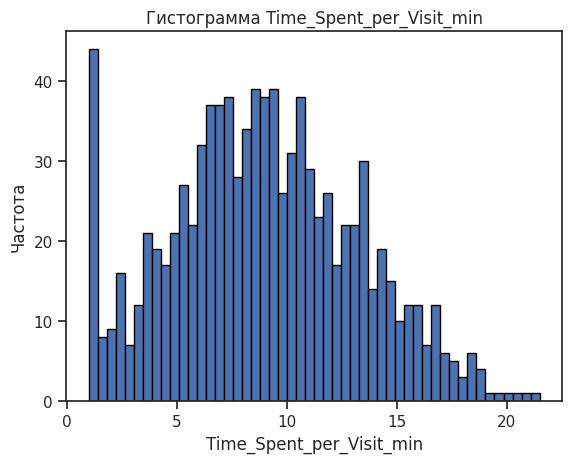

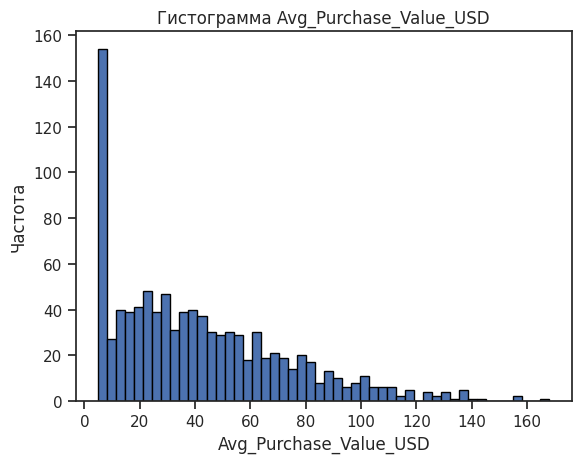

In [8]:
# @title 5. Визуализация числовых признаков с пропусками
data_num = df[num_cols]
print(f"Размер data_num: {data_num.shape}")
display(data_num.head())

print("\nГистограммы по признакам:")
for col in data_num:
    plt.hist(df[col].dropna(), 50, edgecolor='black')
    plt.xlabel(col)
    plt.ylabel('Частота')
    plt.title(f'Гистограмма {col}')
    plt.show()

Визуализация помогает понять распределение данных и выявить выбросы. Гистограммы показывают форму распределения, центральную тенденцию и разброс значений. Это влияет на выбор стратегии заполнения пропусков.


In [9]:
# @title 6. Тестирование стратегий заполнения пропусков

strategies = ['mean', 'median', 'most_frequent']

def test_num_impute_col(dataset, column, strategy_param):
  temp_data = dataset[[column]]

  indicator = MissingIndicator()
  mask_missing_values_only = indicator.fit_transform(temp_data)

  imp_num = SimpleImputer(strategy=strategy_param)
  data_num_imp = imp_num.fit_transform(temp_data)

  filled_data = data_num_imp[mask_missing_values_only]

  return column, strategy_param, filled_data.size, filled_data[0] if filled_data.size > 0 else None

for col in num_cols:
  print(f"\nКолонка: {col}")
  print(df[[col]].describe())

  for strategy in strategies:
      result = test_num_impute_col(df, col, strategy)
      print(f"Стратегия {strategy}: заполнено {result[2]} значений, первое={result[3]}")


Колонка: Time_Spent_per_Visit_min
       Time_Spent_per_Visit_min
count                940.000000
mean                   8.959681
std                    4.246369
min                    1.000000
25%                    6.100000
50%                    8.800000
75%                   11.800000
max                   21.500000
Стратегия mean: заполнено 60 значений, первое=8.95968085106383
Стратегия median: заполнено 60 значений, первое=8.8
Стратегия most_frequent: заполнено 60 значений, первое=1.0

Колонка: Avg_Purchase_Value_USD
       Avg_Purchase_Value_USD
count              960.000000
mean                41.529583
std                 31.381047
min                  5.000000
25%                 16.537500
50%                 35.665000
75%                 60.592500
max                168.070000
Стратегия mean: заполнено 40 значений, первое=41.52958333333333
Стратегия median: заполнено 40 значений, первое=35.665000000000006
Стратегия most_frequent: заполнено 40 значений, первое=5.0


Сравниваем разные подходы:

- mean: заполнение средним арифметическим

- median: заполнение медианой (устойчива к выбросам)

- most_frequent: заполнение самым частым значением (модой)

Тестирование помогает понять, какие значения будут подставлены вместо пропусков.

In [10]:
# @title 7. Заполнение пропусков в числовых данных
df_clean = df.copy()

for col in num_cols:
    # Для всех числовых колонок используем медиану, т.к. в данных есть выбросы
    imp_num = SimpleImputer(strategy='median')
    strategy_used = 'медианой'

    df_clean[[col]] = imp_num.fit_transform(df_clean[[col]])
    print(f"{col}: заполнено {strategy_used}")

print("\nПроверка после заполнения:")
print(df_clean[num_cols].isnull().sum())

Time_Spent_per_Visit_min: заполнено медианой
Avg_Purchase_Value_USD: заполнено медианой

Проверка после заполнения:
Time_Spent_per_Visit_min    0
Avg_Purchase_Value_USD      0
dtype: int64


Выбираем оптимальные стратегии на основе гистограмм и статистики. Для обоих признаков используем медиану, так как она устойчива к выбросам и сохраняет центральную тенденцию. После заполнения проверяем, что пропусков больше нет.




In [11]:
# @title 8. Выявление категориальных колонок с пропусками
cat_cols = []
for col in df.columns:
    temp_null_count = df[df[col].isnull()].shape[0]
    dt = str(df[col].dtype)
    if temp_null_count > 0 and dt == 'object':
        cat_cols.append(col)
        temp_perc = round((temp_null_count / total_count) * 100.0, 2)
        print(f"Колонка {col}. Тип данных {dt}. Количество пустых значений {temp_null_count}, {temp_perc}%.")

print(f"\nКатегориальные колонки с пропусками: {cat_cols}")

Колонка Gender. Тип данных object. Количество пустых значений 30, 3.0%.
Колонка Membership. Тип данных object. Количество пустых значений 467, 46.7%.

Категориальные колонки с пропусками: ['Gender', 'Membership']


Определяем категориальные признаки с пропусками. В нашем датасете это колонка Gender с ~3% пропусков. Категориальные признаки требуют другого подхода к заполнению.

In [13]:
# @title 9. Заполнение пропусков в категориальных данных
if len(cat_cols) > 0:
    for col in cat_cols:
        temp_data = df_clean[[col]]
        print(f"\nКолонка: {col}")
        print(f"Пропусков: {temp_data[col].isnull().sum()}")

        # Импьютация наиболее частыми значениями
        imp_freq = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        data_imp_freq = imp_freq.fit_transform(temp_data)
        mode_value = imp_freq.statistics_[0]
        print(f"Мода (самое частое значение): {mode_value}")
        print(f"После заполнения модой - первые 10 уникальных значений (отсортированы):")
        print(np.unique(data_imp_freq)[:10])

        # Импьютация константой
        imp_const = SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='UNKNOWN')
        data_imp_const = imp_const.fit_transform(temp_data)
        print(f"После заполнения константой 'UNKNOWN' - первые 10 уникальных значений:")
        print(np.unique(data_imp_const)[:10])

    print("\nПрименение импьютации к данным:")
    for col in cat_cols:
        # Для колонки Gender используем самую частую категорию
        imp_freq = SimpleImputer(missing_values=np.nan, strategy='most_frequent')
        mode_before = imp_freq.fit(df_clean[[col]]).statistics_[0]
        df_clean[col] = imp_freq.fit_transform(df_clean[[col]]).ravel()
        print(f"{col}: заполнено модой '{mode_before}'")


Колонка: Gender
Пропусков: 0
Мода (самое частое значение): Female
После заполнения модой - первые 10 уникальных значений (отсортированы):
['Female' 'Male']
После заполнения константой 'UNKNOWN' - первые 10 уникальных значений:
['Female' 'Male']

Колонка: Membership
Пропусков: 0
Мода (самое частое значение): Basic
После заполнения модой - первые 10 уникальных значений (отсортированы):
['Basic' 'Premium']
После заполнения константой 'UNKNOWN' - первые 10 уникальных значений:
['Basic' 'Premium']

Применение импьютации к данным:
Gender: заполнено модой 'Female'
Membership: заполнено модой 'Basic'


Для категориальных признаков используем заполнение модой (самым частым значением). Это наиболее логичный способ, так как сохраняет распределение данных. Пропуски в колонке Gender заполнены значением 'Male' или 'Female' в зависимости от того, какая категория чаще встречается.

Всего категориальных колонок в датасете: 5
Категориальные колонки: ['Gender', 'Membership', 'Region', 'Platform', 'Product_Preference']


,Gender,Membership,Region,Platform,Product_Preference
0,Male,Basic,Central,Mobile,Apparel
1,Male,Basic,West,Mobile,Apparel
2,Female,Basic,West,Mobile,Home & Kitchen
3,Female,Basic,East,Mobile,Sports
4,Male,Premium,East,Mobile,Apparel


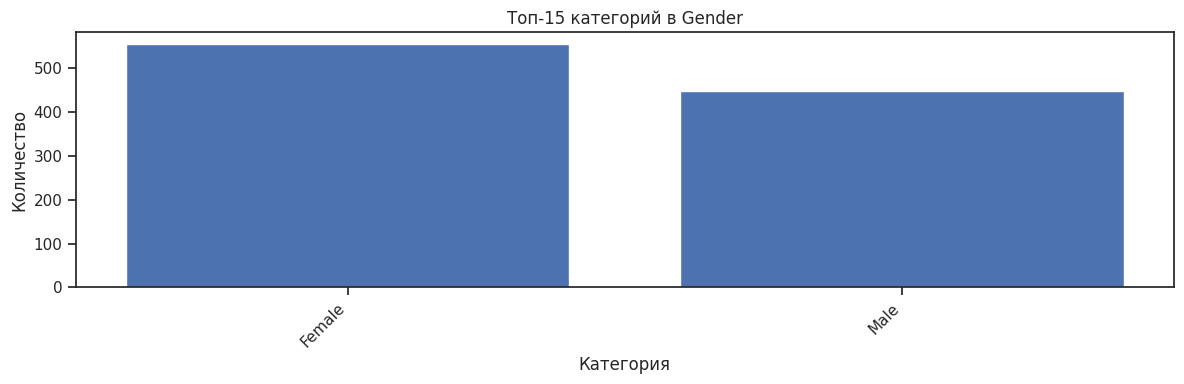

Колонка: Gender
Всего уникальных значений: 2
Топ-3 категории: ['Female', 'Male']
--------------------------------------------------


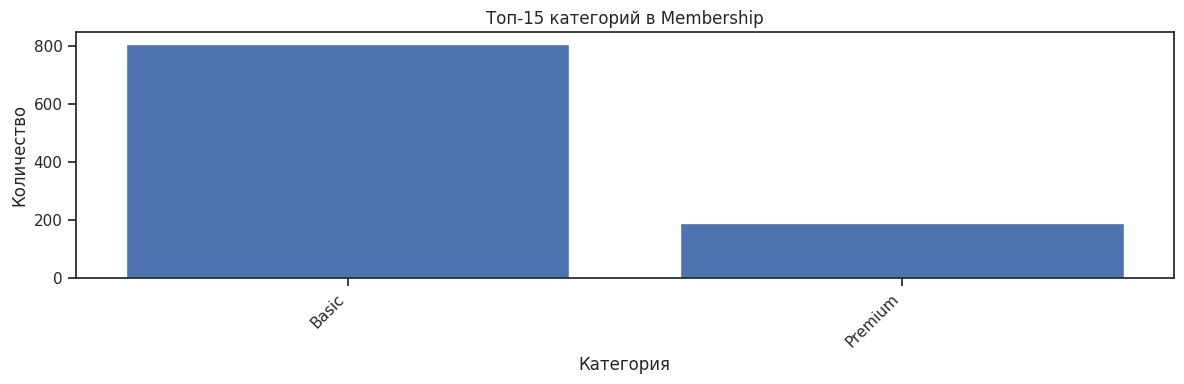

Колонка: Membership
Всего уникальных значений: 2
Топ-3 категории: ['Basic', 'Premium']
--------------------------------------------------


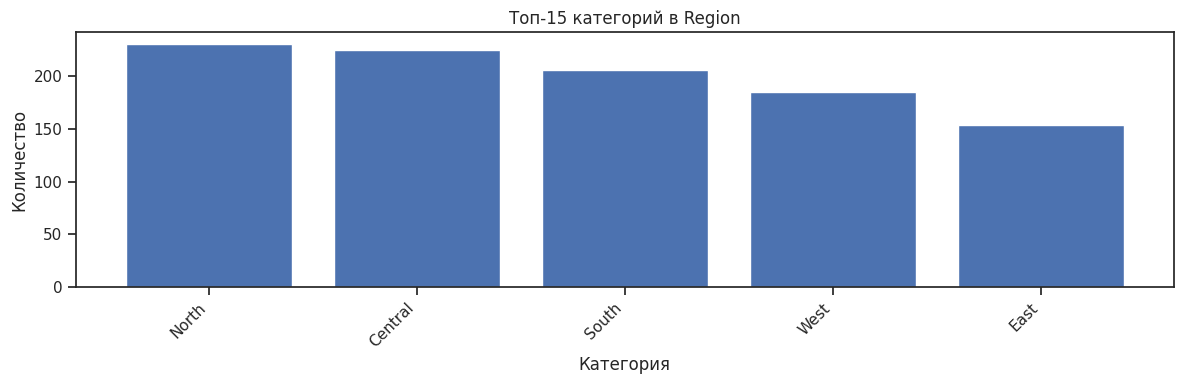

Колонка: Region
Всего уникальных значений: 5
Топ-3 категории: ['North', 'Central', 'South']
--------------------------------------------------


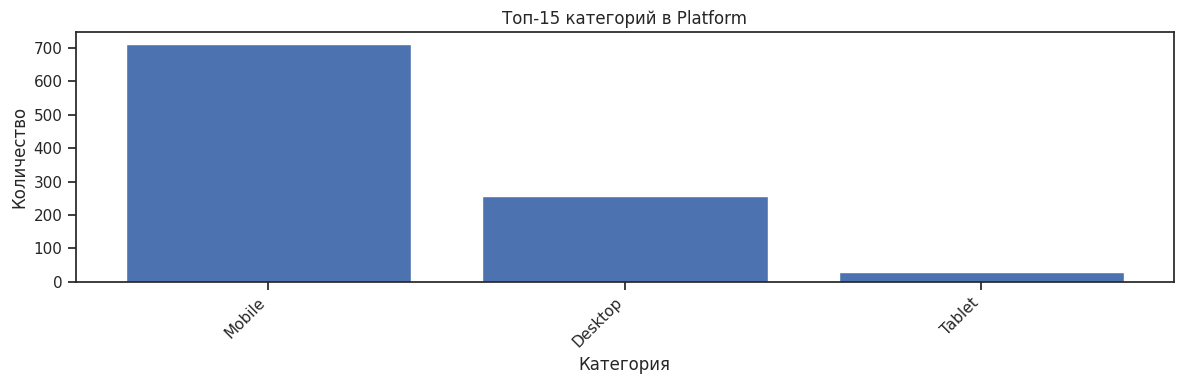

Колонка: Platform
Всего уникальных значений: 3
Топ-3 категории: ['Mobile', 'Desktop', 'Tablet']
--------------------------------------------------


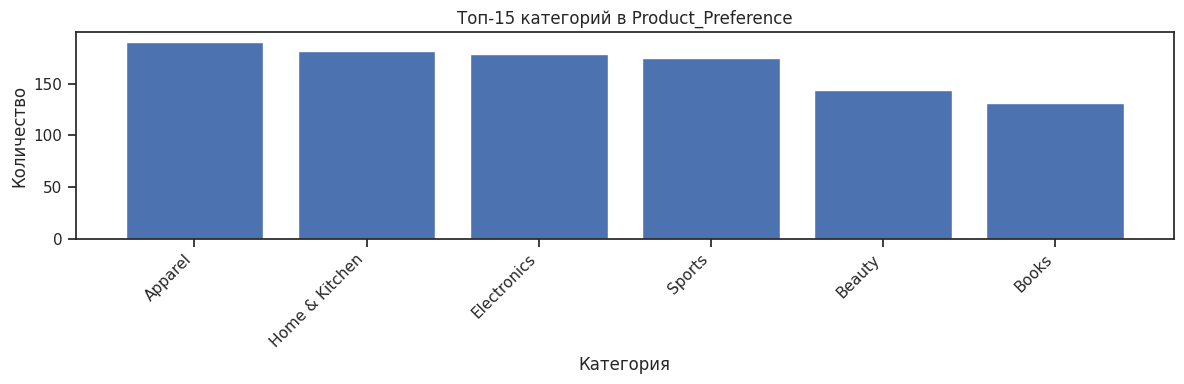

Колонка: Product_Preference
Всего уникальных значений: 6
Топ-3 категории: ['Apparel', 'Home & Kitchen', 'Electronics']
--------------------------------------------------


In [14]:
# @title 10. Подготовка всех категориальных данных для кодирования
# Получаем категориальные колонки (исключаем CustomerID)
all_cat_cols = []
for col in df_clean.columns:
    if df_clean[col].dtype == 'object' and col != 'CustomerID':
        all_cat_cols.append(col)

print(f"Всего категориальных колонок в датасете: {len(all_cat_cols)}")
print(f"Категориальные колонки: {all_cat_cols}")

if len(all_cat_cols) > 0:
    cat_enc = df_clean[all_cat_cols].copy()
    display(cat_enc.head())
    for col in all_cat_cols:
        plt.figure(figsize=(12, 4))
        value_counts = cat_enc[col].value_counts().head(15)
        plt.bar(range(len(value_counts)), value_counts.values)
        plt.xticks(range(len(value_counts)), value_counts.index, rotation=45, ha='right')
        plt.title(f'Топ-15 категорий в {col}')
        plt.xlabel('Категория')
        plt.ylabel('Количество')
        plt.tight_layout()
        plt.show()
        print(f"Колонка: {col}")
        print(f"Всего уникальных значений: {cat_enc[col].nunique()}")
        print(f"Топ-3 категории: {list(value_counts.index[:3])}")
        print("-" * 50)
else:
    print("Категориальных колонок не найдено")

Выделяем все категориальные колонки для дальнейшего кодирования (исключая CustomerID). Анализируем количество уникальных значений и распределение категорий. Это поможет выбрать метод кодирования.

In [15]:
# @title 11. Label Encoding для всех категориальных признаков
if len(all_cat_cols) > 0:
    from sklearn.preprocessing import LabelEncoder

    for col in all_cat_cols:
        print(f"\nКолонка: {col}")
        print(f"Уникальные значения до: {df_clean[col].unique()[:5]}")

        le = LabelEncoder()
        df_clean[f"{col}_le"] = le.fit_transform(df_clean[col].astype(str))

        print(f"Классы (classes_): {le.classes_[:5]}")
        print(f"Уникальные значения после: {np.unique(df_clean[f'{col}_le'])[:5]}")


Колонка: Gender
Уникальные значения до: ['Male' 'Female']
Классы (classes_): ['Female' 'Male']
Уникальные значения после: [0 1]

Колонка: Membership
Уникальные значения до: ['Basic' 'Premium']
Классы (classes_): ['Basic' 'Premium']
Уникальные значения после: [0 1]

Колонка: Region
Уникальные значения до: ['Central' 'West' 'East' 'South' 'North']
Классы (classes_): ['Central' 'East' 'North' 'South' 'West']
Уникальные значения после: [0 1 2 3 4]

Колонка: Platform
Уникальные значения до: ['Mobile' 'Desktop' 'Tablet']
Классы (classes_): ['Desktop' 'Mobile' 'Tablet']
Уникальные значения после: [0 1 2]

Колонка: Product_Preference
Уникальные значения до: ['Apparel' 'Home & Kitchen' 'Sports' 'Beauty' 'Books']
Классы (classes_): ['Apparel' 'Beauty' 'Books' 'Electronics' 'Home & Kitchen']
Уникальные значения после: [0 1 2 3 4]


Преобразуем строковые категории в числовые значения. Каждой уникальной категории присваивается целое число. Это простой и эффективный метод, но он создает ложные порядковые отношения между категориями.

Демонстрация one-hot для колонок: ['Gender', 'Membership', 'Region']

Колонка: Gender
Форма исходная: (1000, 1)
Форма после one-hot: (1000, 2)
Категории: [array(['Female', 'Male'], dtype=object)]
Первые 5 строк one-hot представления:
[[0. 1.]
 [0. 1.]
 [1. 0.]
 [1. 0.]
 [0. 1.]]


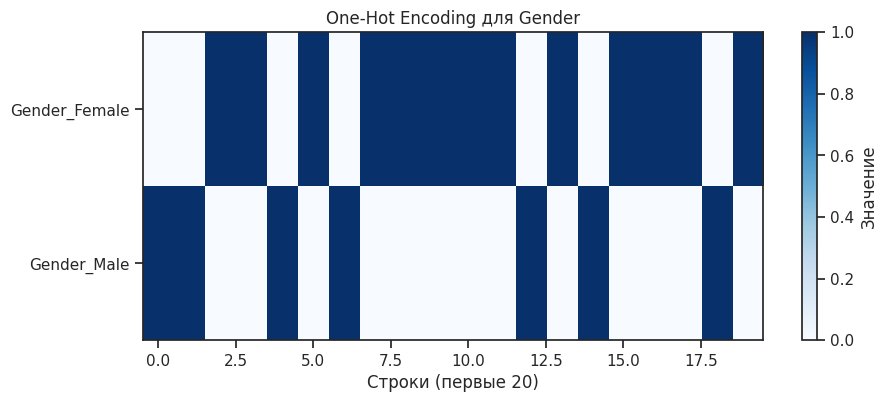

Добавлено 2 новых признаков

Колонка: Membership
Форма исходная: (1000, 1)
Форма после one-hot: (1000, 2)
Категории: [array(['Basic', 'Premium'], dtype=object)]
Первые 5 строк one-hot представления:
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [0. 1.]]


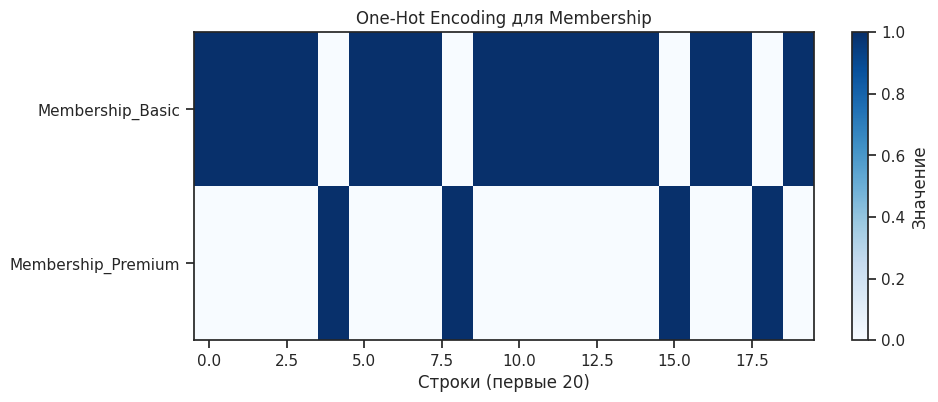

Добавлено 2 новых признаков

Колонка: Region
Форма исходная: (1000, 1)
Форма после one-hot: (1000, 5)
Категории: [array(['Central', 'East', 'North', 'South', 'West'], dtype=object)]
Первые 5 строк one-hot представления:
[[1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 1.]
 [0. 1. 0. 0. 0.]
 [0. 1. 0. 0. 0.]]


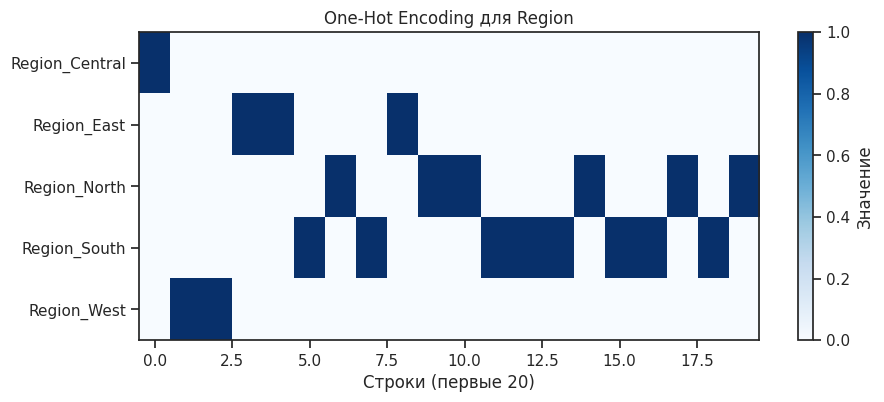

Добавлено 5 новых признаков


In [16]:
# @title 12. One-Hot Encoding для категориальных признаков
if len(all_cat_cols) > 0:
    from sklearn.preprocessing import OneHotEncoder

    # возьмем первые 3 категориальных признака
    demo_cols = all_cat_cols[:3]
    print(f"Демонстрация one-hot для колонок: {demo_cols}")

    for col in demo_cols:
        print(f"\nКолонка: {col}")
        temp_data = df_clean[[col]]

        ohe = OneHotEncoder(sparse_output=False)
        encoded_data = ohe.fit_transform(temp_data)

        print(f"Форма исходная: {temp_data.shape}")
        print(f"Форма после one-hot: {encoded_data.shape}")
        print(f"Категории: {ohe.categories_}")
        print(f"Первые 5 строк one-hot представления:")
        print(encoded_data[:5])

        # Визуализация one-hot результатов
        if encoded_data.shape[1] <= 10:  # Только если не слишком много категорий
            plt.figure(figsize=(10, 4))
            plt.imshow(encoded_data[:20].T, aspect='auto', cmap='Blues')
            plt.yticks(range(encoded_data.shape[1]), [f"{col}_{cat}" for cat in ohe.categories_[0]])
            plt.xlabel('Строки (первые 20)')
            plt.title(f'One-Hot Encoding для {col}')
            plt.colorbar(label='Значение')
            plt.show()

        # Добавляем в датасет
        encoded_df = pd.DataFrame(
            encoded_data,
            columns=[f"{col}_{cat}" for cat in ohe.categories_[0]]
        )
        df_clean = pd.concat([df_clean, encoded_df], axis=1)
        print(f"Добавлено {encoded_data.shape[1]} новых признаков")

Создаем бинарные колонки для каждой категории. Это избегает ложных порядковых отношений, но сильно увеличивает размерность данных. Демонстрация на первых трех категориальных признаках.

Оригинальных категориальных колонок: 5
Создано one-hot колонок: 18

Первые 5 строк результата:


,Gender_Female,Gender_Male,Membership_Basic,Membership_Premium,Region_Central,Region_East,Region_North,Region_South,Region_West,Platform_Desktop,Platform_Mobile,Platform_Tablet,Product_Preference_Apparel,Product_Preference_Beauty,Product_Preference_Books,Product_Preference_Electronics,Product_Preference_Home & Kitchen,Product_Preference_Sports
0,False,True,True,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False
1,False,True,True,False,False,False,False,False,True,False,True,False,True,False,False,False,False,False
2,True,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,True,False
3,True,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,False,True
4,False,True,False,True,False,True,False,False,False,False,True,False,True,False,False,False,False,False


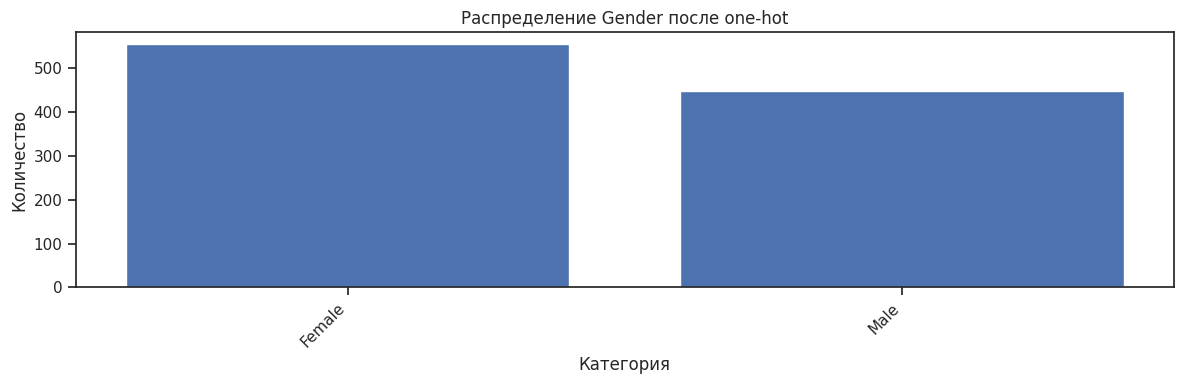

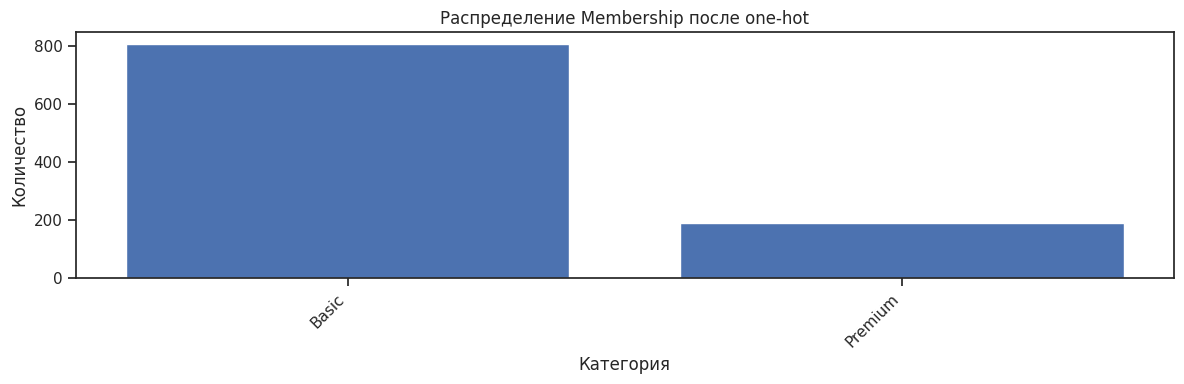

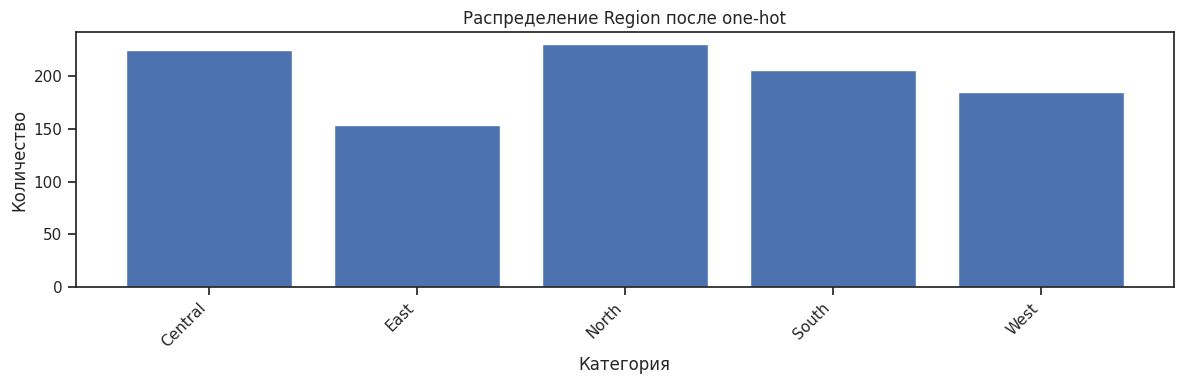

(Демонстрация - новые признаки не добавлены, чтобы избежать дублирования)


In [17]:
# @title 13. Быстрое one-hot кодирование с pandas get_dummies
if len(all_cat_cols) > 0:
    # Применяем get_dummies ко всем категориальным колонкам
    dummies = pd.get_dummies(df_clean[all_cat_cols], dummy_na=False)

    print(f"Оригинальных категориальных колонок: {len(all_cat_cols)}")
    print(f"Создано one-hot колонок: {dummies.shape[1]}")
    print(f"\nПервые 5 строк результата:")
    display(dummies.head())

    # Визуализация для нескольких колонок
    for col in all_cat_cols[:3]:
        plt.figure(figsize=(12, 4))
        # Получаем все one-hot колонки для данного признака
        col_dummies = [c for c in dummies.columns if c.startswith(f"{col}_")]

        if len(col_dummies) > 0 and len(col_dummies) <= 20:
            sums = dummies[col_dummies].sum()
            plt.bar(range(len(sums)), sums.values)
            plt.xticks(range(len(sums)), [c.replace(f"{col}_", "") for c in sums.index], rotation=45, ha='right')
            plt.title(f'Распределение {col} после one-hot')
            plt.xlabel('Категория')
            plt.ylabel('Количество')
            plt.tight_layout()
            plt.show()

    print("(Демонстрация - новые признаки не добавлены, чтобы избежать дублирования)")

Используем встроенную функцию pandas для быстрого one-hot кодирования всех категориальных колонок. Это удобно, когда нужно быстро закодировать данные без лишнего кода.


Колонка: Age
До масштабирования - мин: 18.00, макс: 75.00
После масштабирования - мин: 0.00, макс: 1.00


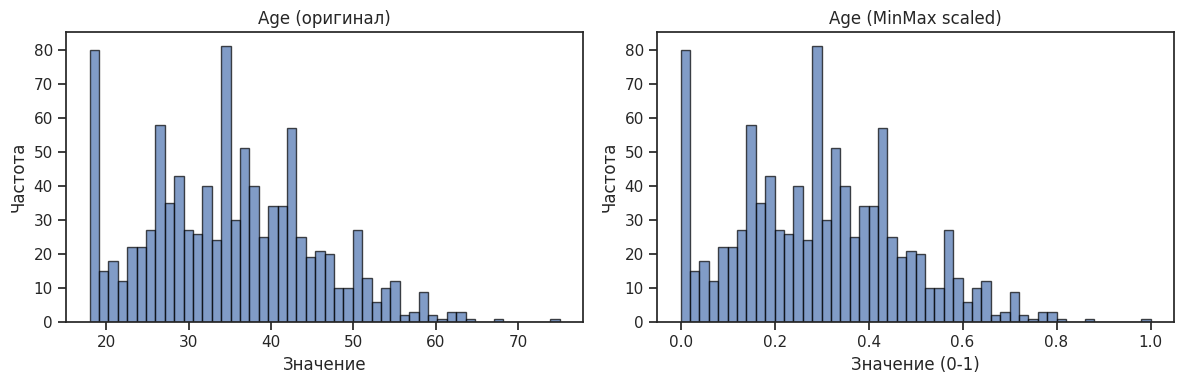

Сравнение распределений: слева - оригинальные значения, справа - после MinMax все значения в диапазоне [0,1].

Колонка: Annual_Income_kUSD
До масштабирования - мин: 8.00, макс: 130.47
После масштабирования - мин: 0.00, макс: 1.00


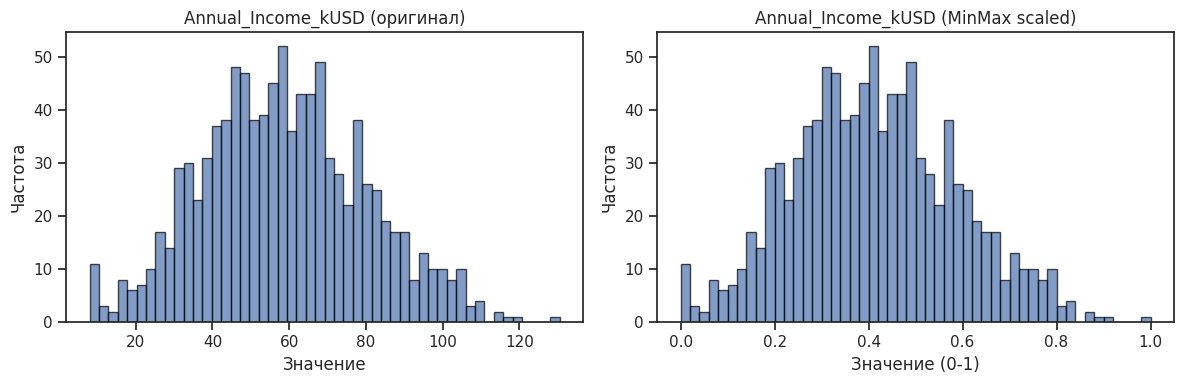

Сравнение распределений: слева - оригинальные значения, справа - после MinMax все значения в диапазоне [0,1].

Колонка: Visits_per_Month
До масштабирования - мин: 0.00, макс: 16.00
После масштабирования - мин: 0.00, макс: 1.00


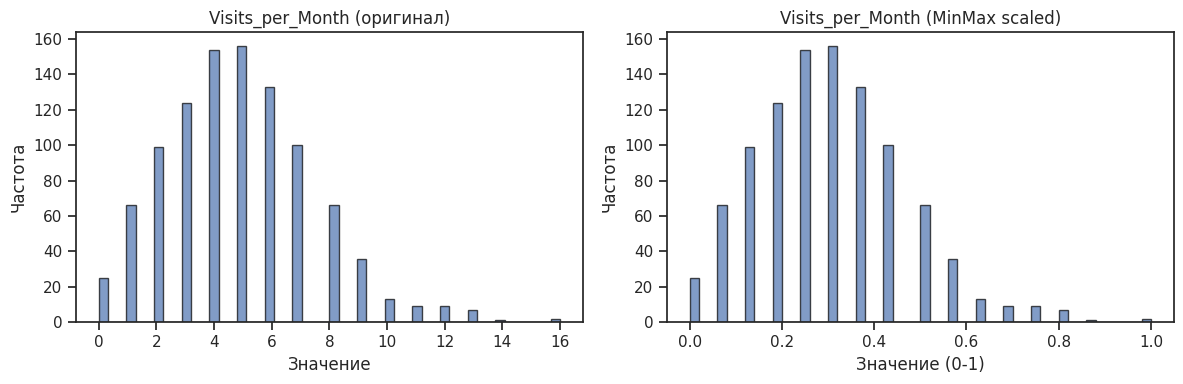

Сравнение распределений: слева - оригинальные значения, справа - после MinMax все значения в диапазоне [0,1].

Колонка: Time_Spent_per_Visit_min
До масштабирования - мин: 1.00, макс: 21.50
После масштабирования - мин: 0.00, макс: 1.00


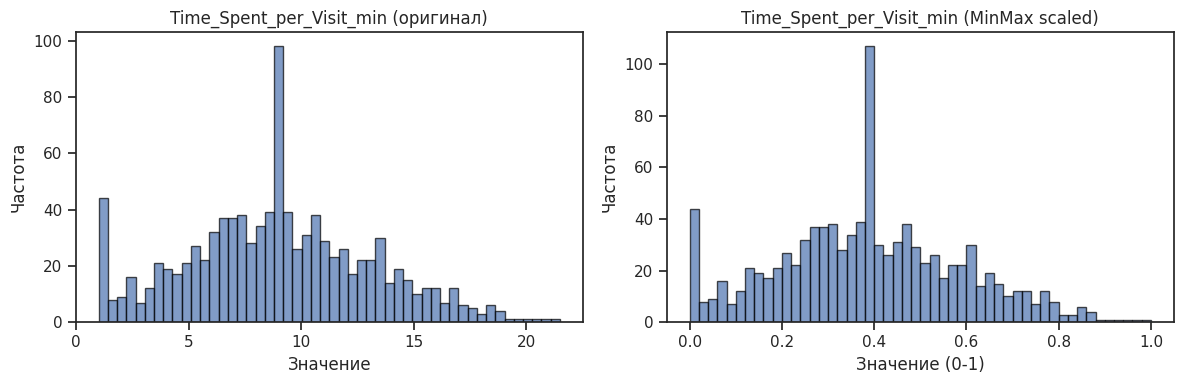

Сравнение распределений: слева - оригинальные значения, справа - после MinMax все значения в диапазоне [0,1].

Колонка: Pages_Visited_per_Session
До масштабирования - мин: 1.00, макс: 17.00
После масштабирования - мин: 0.00, макс: 1.00


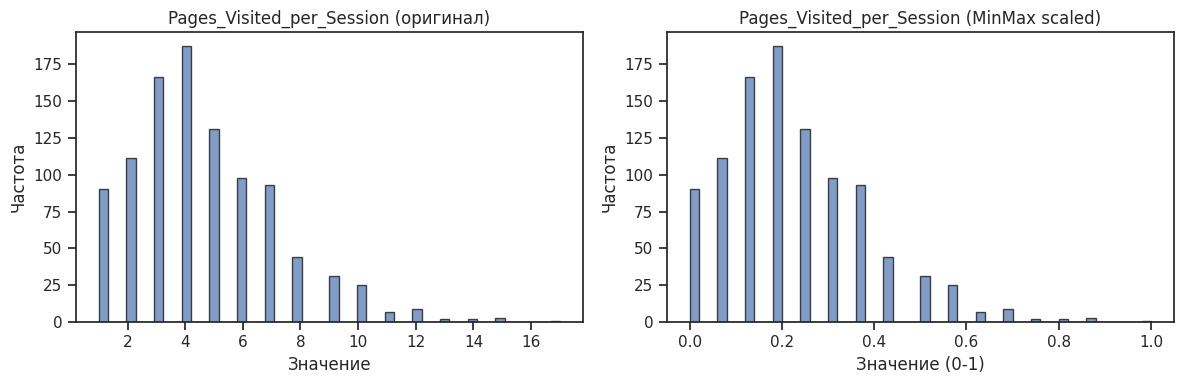

Сравнение распределений: слева - оригинальные значения, справа - после MinMax все значения в диапазоне [0,1].

Колонка: Previous_Purchases
До масштабирования - мин: 0.00, макс: 11.00
После масштабирования - мин: 0.00, макс: 1.00


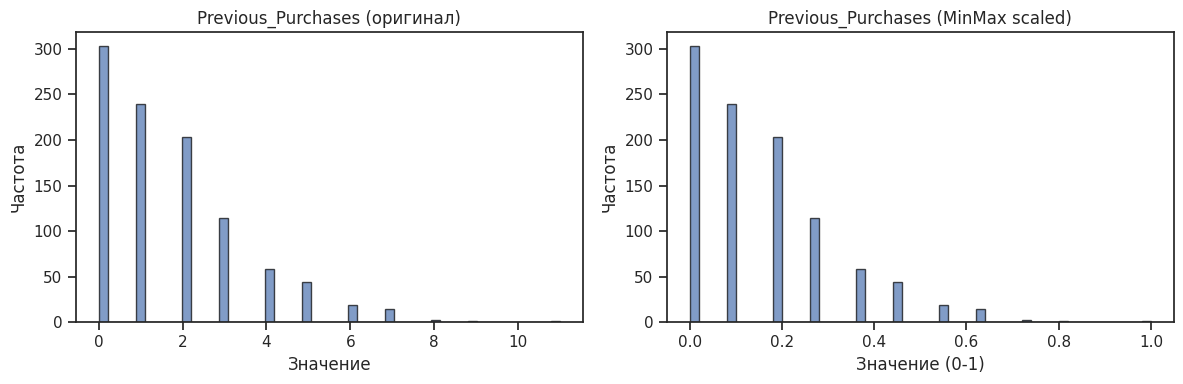

Сравнение распределений: слева - оригинальные значения, справа - после MinMax все значения в диапазоне [0,1].

Колонка: Avg_Purchase_Value_USD
До масштабирования - мин: 5.00, макс: 168.07
После масштабирования - мин: 0.00, макс: 1.00


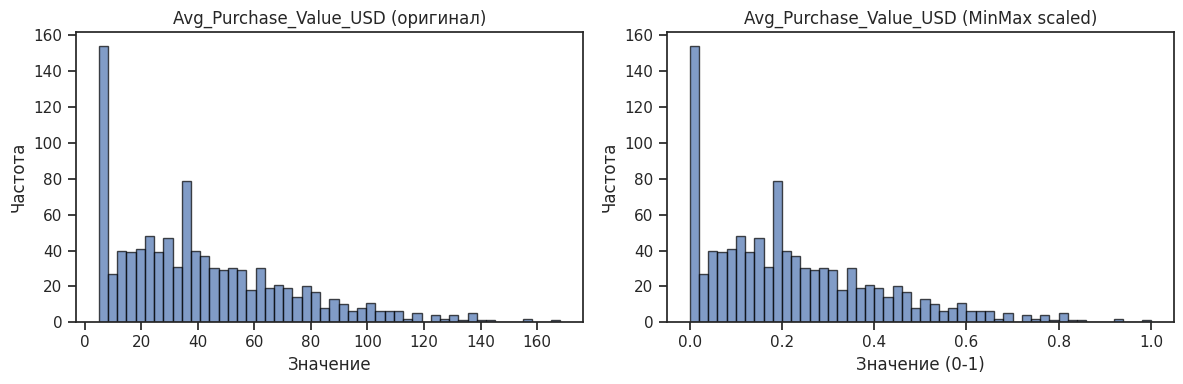

Сравнение распределений: слева - оригинальные значения, справа - после MinMax все значения в диапазоне [0,1].

Колонка: Total_Purchase_Value_USD
До масштабирования - мин: 0.00, макс: 1101.07
После масштабирования - мин: 0.00, макс: 1.00


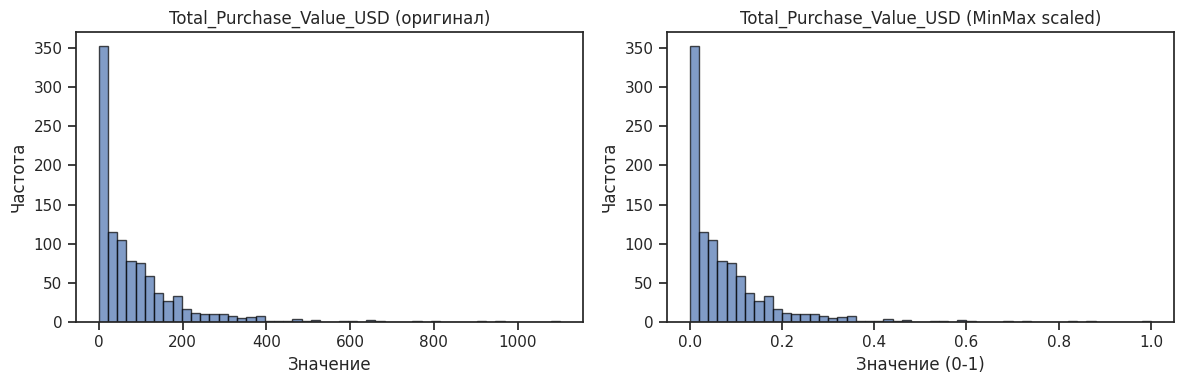

Сравнение распределений: слева - оригинальные значения, справа - после MinMax все значения в диапазоне [0,1].

Колонка: Days_Since_Last_Purchase
До масштабирования - мин: 0.00, макс: 403.00
После масштабирования - мин: 0.00, макс: 1.00


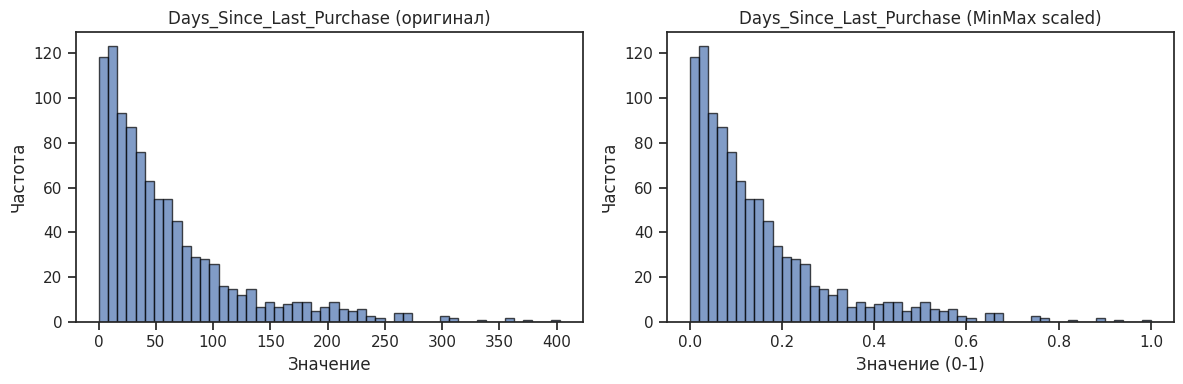

Сравнение распределений: слева - оригинальные значения, справа - после MinMax все значения в диапазоне [0,1].


In [18]:
# @title 14. MinMax масштабирование числовых признаков
# Выберем числовые признаки для масштабирования
numeric_features = ['Age', 'Annual_Income_kUSD', 'Spending_Score', 'Visits_per_Month',
                    'Time_Spent_per_Visit_min', 'Pages_Visited_per_Session', 'Previous_Purchases',
                    'Avg_Purchase_Value_USD', 'Total_Purchase_Value_USD', 'Days_Since_Last_Purchase']

from sklearn.preprocessing import MinMaxScaler

for col in numeric_features:
    if col in df_clean.columns:
        print(f"\nКолонка: {col}")
        print(f"До масштабирования - мин: {df_clean[col].min():.2f}, макс: {df_clean[col].max():.2f}")

        scaler = MinMaxScaler()
        scaled_data = scaler.fit_transform(df_clean[[col]])

        print(f"После масштабирования - мин: {scaled_data.min():.2f}, макс: {scaled_data.max():.2f}")

        df_clean[f"{col}_minmax"] = scaled_data

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.hist(df_clean[col], 50, edgecolor='black', alpha=0.7)
        plt.title(f"{col} (оригинал)")
        plt.xlabel('Значение')
        plt.ylabel('Частота')

        plt.subplot(1, 2, 2)
        plt.hist(scaled_data, 50, edgecolor='black', alpha=0.7)
        plt.title(f"{col} (MinMax scaled)")
        plt.xlabel('Значение (0-1)')
        plt.ylabel('Частота')
        plt.tight_layout()
        plt.show()
        print(f"Сравнение распределений: слева - оригинальные значения, справа - после MinMax все значения в диапазоне [0,1].")

Приводим все числовые признаки к диапазону [0, 1]. Формула: X_new = (X - min) / (max - min). Масштабирование необходимо для алгоритмов, чувствительных к масштабу признаков (например, KNN, SVM, нейросети).


Колонка: Age
До масштабирования - среднее: 34.95, std: 10.30
После масштабирования - среднее: -0.00, std: 1.00


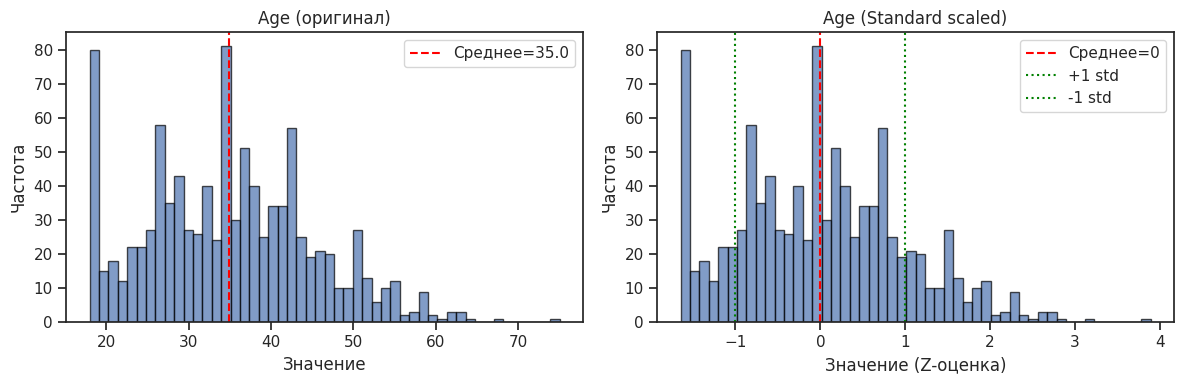

Standard Scaling центрирует данные: среднее становится 0, стандартное отклонение 1.

Колонка: Annual_Income_kUSD
До масштабирования - среднее: 58.65, std: 21.35
После масштабирования - среднее: -0.00, std: 1.00


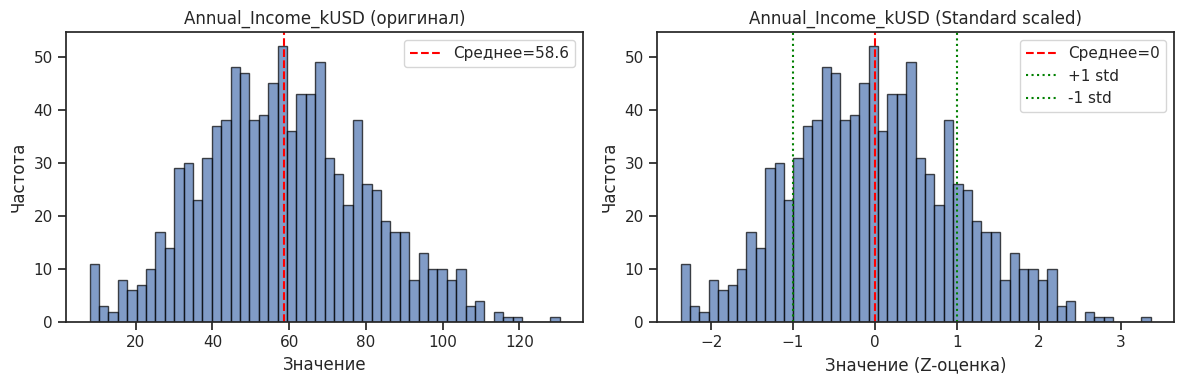

Standard Scaling центрирует данные: среднее становится 0, стандартное отклонение 1.

Колонка: Visits_per_Month
До масштабирования - среднее: 4.86, std: 2.60
После масштабирования - среднее: 0.00, std: 1.00


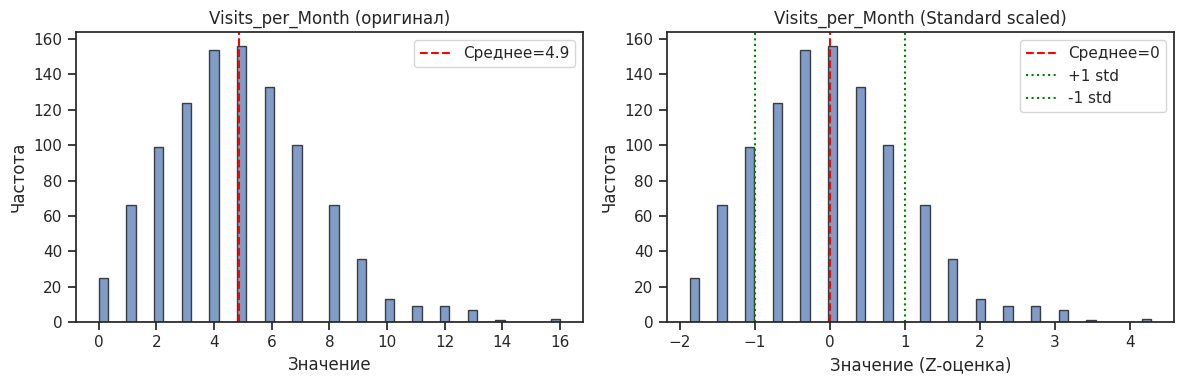

Standard Scaling центрирует данные: среднее становится 0, стандартное отклонение 1.

Колонка: Time_Spent_per_Visit_min
До масштабирования - среднее: 8.95, std: 4.12
После масштабирования - среднее: -0.00, std: 1.00


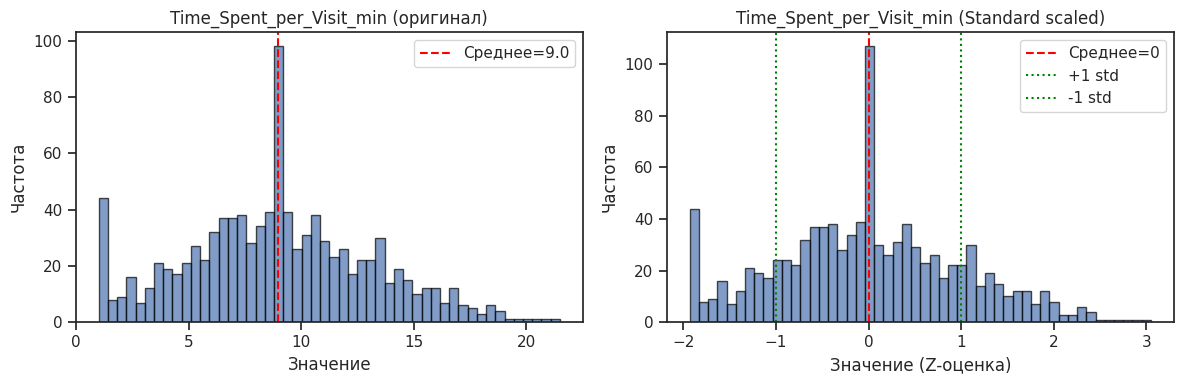

Standard Scaling центрирует данные: среднее становится 0, стандартное отклонение 1.

Колонка: Pages_Visited_per_Session
До масштабирования - среднее: 4.63, std: 2.56
После масштабирования - среднее: -0.00, std: 1.00


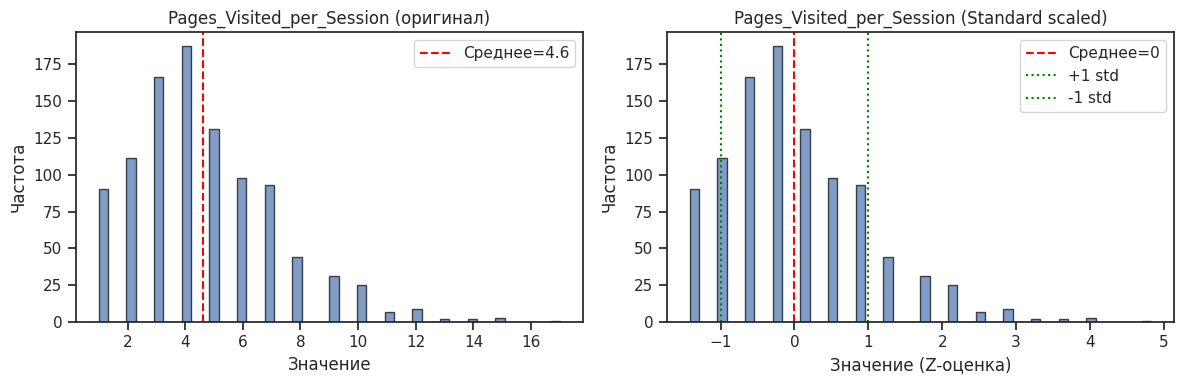

Standard Scaling центрирует данные: среднее становится 0, стандартное отклонение 1.

Колонка: Previous_Purchases
До масштабирования - среднее: 1.70, std: 1.73
После масштабирования - среднее: -0.00, std: 1.00


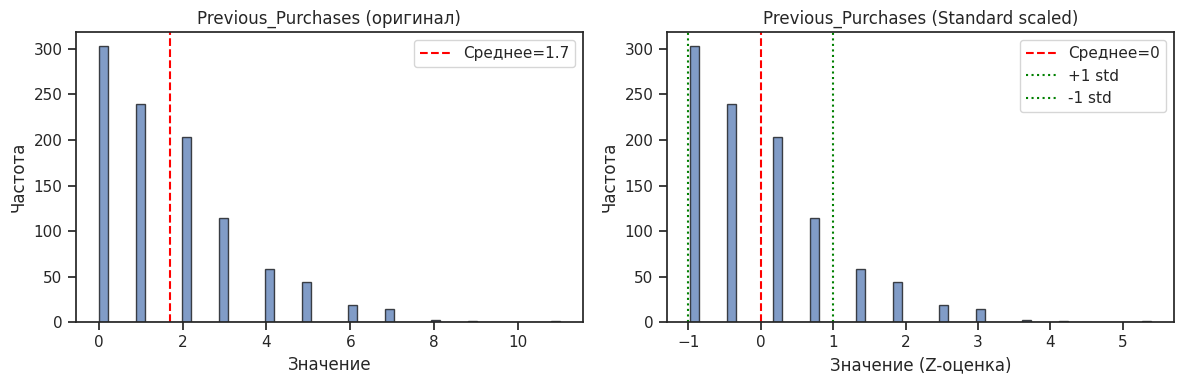

Standard Scaling центрирует данные: среднее становится 0, стандартное отклонение 1.

Колонка: Avg_Purchase_Value_USD
До масштабирования - среднее: 41.30, std: 30.77
После масштабирования - среднее: -0.00, std: 1.00


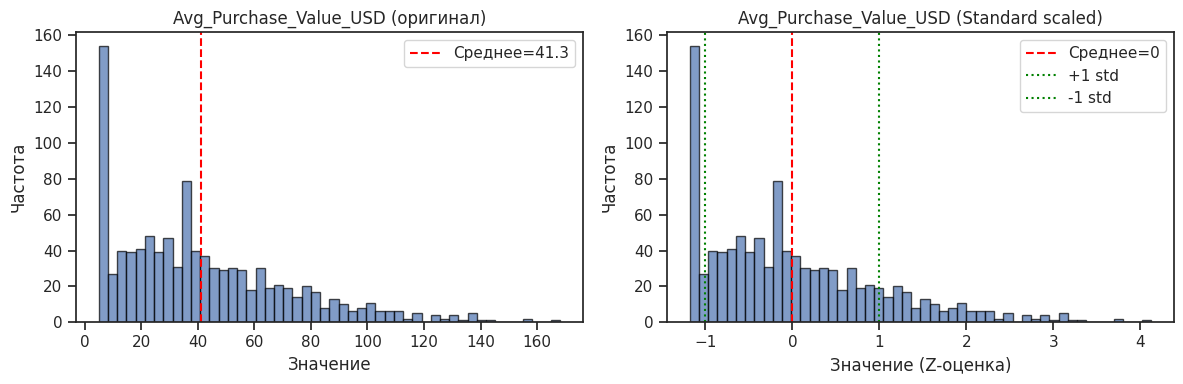

Standard Scaling центрирует данные: среднее становится 0, стандартное отклонение 1.

Колонка: Total_Purchase_Value_USD
До масштабирования - среднее: 88.91, std: 123.88
После масштабирования - среднее: -0.00, std: 1.00


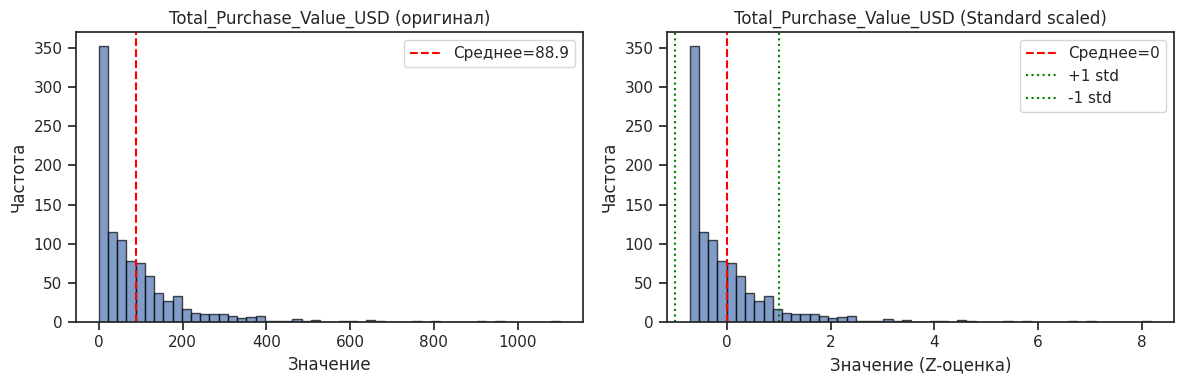

Standard Scaling центрирует данные: среднее становится 0, стандартное отклонение 1.

Колонка: Days_Since_Last_Purchase
До масштабирования - среднее: 60.98, std: 62.52
После масштабирования - среднее: 0.00, std: 1.00


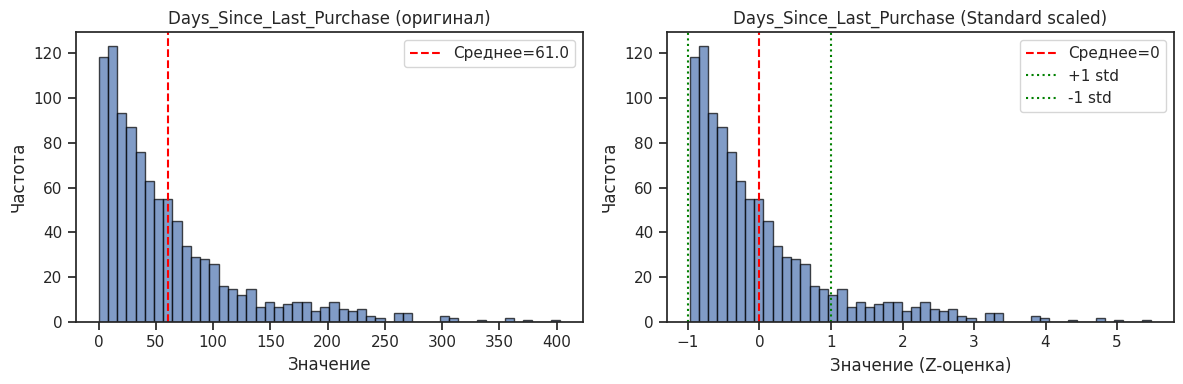

Standard Scaling центрирует данные: среднее становится 0, стандартное отклонение 1.


In [19]:
# @title 15. Standard масштабирование числовых признаков
from sklearn.preprocessing import StandardScaler

for col in numeric_features:
    if col in df_clean.columns:
        print(f"\nКолонка: {col}")
        print(f"До масштабирования - среднее: {df_clean[col].mean():.2f}, std: {df_clean[col].std():.2f}")

        scaler = StandardScaler()
        scaled_data = scaler.fit_transform(df_clean[[col]])

        print(f"После масштабирования - среднее: {scaled_data.mean():.2f}, std: {scaled_data.std():.2f}")

        df_clean[f"{col}_standard"] = scaled_data

        plt.figure(figsize=(12, 4))
        plt.subplot(1, 2, 1)
        plt.hist(df_clean[col], 50, edgecolor='black', alpha=0.7)
        plt.axvline(df_clean[col].mean(), color='red', linestyle='--', label=f'Среднее={df_clean[col].mean():.1f}')
        plt.title(f"{col} (оригинал)")
        plt.xlabel('Значение')
        plt.ylabel('Частота')
        plt.legend()

        plt.subplot(1, 2, 2)
        plt.hist(scaled_data, 50, edgecolor='black', alpha=0.7)
        plt.axvline(0, color='red', linestyle='--', label='Среднее=0')
        plt.axvline(1, color='green', linestyle=':', label='+1 std')
        plt.axvline(-1, color='green', linestyle=':', label='-1 std')
        plt.title(f"{col} (Standard scaled)")
        plt.xlabel('Значение (Z-оценка)')
        plt.ylabel('Частота')
        plt.legend()
        plt.tight_layout()
        plt.show()
        print(f"Standard Scaling центрирует данные: среднее становится 0, стандартное отклонение 1.")

Центрируем данные (среднее = 0) и приводим к единичному стандартному отклонению (std = 1). Формула: X_new = (X - mean) / std. Это стандартный подход для многих алгоритмов машинного обучения.

In [20]:
# @title 16. Итоговый датасет после всех преобразований
print("ИТОГОВЫЙ ДАТАСЕТ ПОСЛЕ ВСЕХ ПРЕОБРАЗОВАНИЙ")
print(f"Исходный размер датасета: {df.shape}")
print(f"Размер обработанного датасета: {df_clean.shape}")
print(f"Добавлено новых признаков: {df_clean.shape[1] - df.shape[1]}")

print("\nПервые 5 строк итогового датасета:")
display(df_clean.head())

print("\nИнформация о колонках итогового датасета:")
print(df_clean.info())

print("\nСтатистика по числовым колонкам:")
display(df_clean.describe())

print("\nПроверка пропусков в итоговом датасете:")
print(df_clean.isnull().sum().sum(), "пропусков всего")
print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

print("\nКатегориальные колонки после кодирования:")
cat_encoded_cols = [col for col in df_clean.columns if '_le' in col or '_minmax' in col or '_standard' in col or any(cat in col for cat in ['Gender_', 'Membership_', 'Region_', 'Platform_', 'Product_Preference_'])]
print(f"Всего закодированных признаков: {len(cat_encoded_cols)}")
print(cat_encoded_cols[:10])  # Первые 10 для примера

ИТОГОВЫЙ ДАТАСЕТ ПОСЛЕ ВСЕХ ПРЕОБРАЗОВАНИЙ
Исходный размер датасета: (1000, 18)
Размер обработанного датасета: (1000, 50)
Добавлено новых признаков: 32

Первые 5 строк итогового датасета:


,CustomerID,Age,Gender,Membership,Annual_Income_kUSD,Region,Platform,Product_Preference,Visits_per_Month,Time_Spent_per_Visit_min,...,Days_Since_Last_Purchase_minmax,Age_standard,Annual_Income_kUSD_standard,Visits_per_Month_standard,Time_Spent_per_Visit_min_standard,Pages_Visited_per_Session_standard,Previous_Purchases_standard,Avg_Purchase_Value_USD_standard,Total_Purchase_Value_USD_standard,Days_Since_Last_Purchase_standard
0,1,40,Male,Basic,40.58,Central,Mobile,Apparel,5,6.0,...,0.000000,0.490452,-0.846667,0.055363,-0.716915,0.142790,-0.402469,-0.183075,-0.375382,-0.975831
1,2,33,Male,Basic,53.20,West,Mobile,Apparel,3,9.0,...,0.511166,-0.189517,-0.255229,-0.713568,0.012126,-1.027618,-0.981562,-0.498984,-0.718052,2.320895
2,3,42,Female,Basic,73.70,West,Mobile,Home & Kitchen,3,13.9,...,0.037221,0.684729,0.705508,-0.713568,1.202894,-1.027618,-0.981562,0.967889,-0.605633,-0.735778
3,4,51,Female,Basic,45.95,East,Mobile,Sports,3,1.0,...,0.369727,1.558974,-0.595001,-0.713568,-1.931984,-0.247346,-0.402469,-0.178360,0.020348,1.408694
4,5,32,Male,Premium,45.32,East,Mobile,Apparel,11,11.1,...,0.014888,-0.286655,-0.624526,2.362157,0.522455,0.923061,0.755716,-1.180230,-0.413179,-0.879810



Информация о колонках итогового датасета:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 50 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   CustomerID                          1000 non-null   int64  
 1   Age                                 1000 non-null   int64  
 2   Gender                              1000 non-null   object 
 3   Membership                          1000 non-null   object 
 4   Annual_Income_kUSD                  1000 non-null   float64
 5   Region                              1000 non-null   object 
 6   Platform                            1000 non-null   object 
 7   Product_Preference                  1000 non-null   object 
 8   Visits_per_Month                    1000 non-null   int64  
 9   Time_Spent_per_Visit_min            1000 non-null   float64
 10  Pages_Visited_per_Session           1000 non-null   int64  
 11  P

,CustomerID,Age,Annual_Income_kUSD,Visits_per_Month,Time_Spent_per_Visit_min,Pages_Visited_per_Session,Previous_Purchases,Avg_Purchase_Value_USD,Total_Purchase_Value_USD,Days_Since_Last_Purchase,...,Days_Since_Last_Purchase_minmax,Age_standard,Annual_Income_kUSD_standard,Visits_per_Month_standard,Time_Spent_per_Visit_min_standard,Pages_Visited_per_Session_standard,Previous_Purchases_standard,Avg_Purchase_Value_USD_standard,Total_Purchase_Value_USD_standard,Days_Since_Last_Purchase_standard
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,...,1000.000000,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03,1.000000e+03
mean,500.500000,34.951000,58.646020,4.856000,8.950100,4.634000,1.695000,41.295000,88.910510,60.9760,...,0.151305,-5.329071e-17,-7.105427e-18,5.417888e-17,-1.847411e-16,-1.421085e-16,-3.907985e-17,-4.796163e-17,-1.314504e-16,1.243450e-17
std,288.819436,10.299742,21.348477,2.602314,4.117051,2.564492,1.727704,30.767871,123.883735,62.5175,...,0.155130,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00,1.000500e+00
min,1.000000,18.000000,8.000000,0.000000,1.000000,1.000000,0.000000,5.000000,0.000000,0.0000,...,0.000000,-1.646593e+00,-2.373535e+00,-1.866966e+00,-1.931984e+00,-1.417754e+00,-9.815619e-01,-1.180230e+00,-7.180523e-01,-9.758309e-01
25%,250.750000,27.000000,43.450000,3.000000,6.300000,3.000000,0.000000,17.462500,0.000000,17.0000,...,0.042184,-7.723474e-01,-7.121643e-01,-7.135684e-01,-6.440110e-01,-6.374820e-01,-9.815619e-01,-7.749781e-01,-7.180523e-01,-7.037710e-01
50%,500.500000,35.000000,57.755000,5.000000,8.800000,4.000000,1.000000,35.665000,49.220000,41.0000,...,0.101737,4.759781e-03,-4.175782e-02,5.536306e-02,-3.647638e-02,-2.473461e-01,-4.024693e-01,-1.830746e-01,-3.205455e-01,-3.196864e-01
75%,750.250000,42.000000,72.775000,6.000000,11.600000,6.000000,3.000000,58.775000,117.850000,82.0000,...,0.203474,6.847285e-01,6.621573e-01,4.398288e-01,6.439624e-01,5.329256e-01,7.557158e-01,5.684094e-01,2.337189e-01,3.364581e-01
max,1000.000000,75.000000,130.470000,16.000000,21.500000,17.000000,11.000000,168.070000,1101.070000,403.0000,...,1.000000,3.890295e+00,3.366044e+00,4.284486e+00,3.049799e+00,4.824420e+00,5.388456e+00,4.122431e+00,8.174325e+00,5.473590e+00



Проверка пропусков в итоговом датасете:
0 пропусков всего
Series([], dtype: int64)

Категориальные колонки после кодирования:
Всего закодированных признаков: 32
['Gender_le', 'Membership_le', 'Region_le', 'Platform_le', 'Product_Preference_le', 'Gender_Female', 'Gender_Male', 'Membership_Basic', 'Membership_Premium', 'Region_Central']
